In [3]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from pathlib import Path
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Load the customer support tickets CSV
notebook_dir = Path.cwd()
csv_file = notebook_dir.parent.parent / "data" / "raw" / "customer_support_tickets.csv"

df = pd.read_csv(csv_file)

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst example:\n", df.iloc[0])
print("\nTicket Type Distribution:")
print(df["Ticket Type"].value_counts())

Shape: (8469, 17)

Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

First example:
 Ticket ID                                                                       1
Customer Name                                                       Marisa Obrien
Customer Email                                         carrollallison@example.com
Customer Age                                                                   32
Customer Gender                                                             Other
Product Purchased                                                      GoPro Hero
Date of Purchase                                                       2021-03-22
Ticket Type                                             

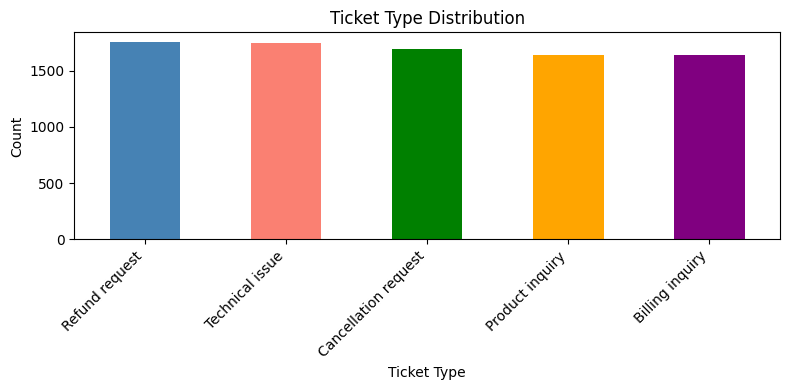

In [5]:
# Plot ticket type distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
df["Ticket Type"].value_counts().plot(
    kind="bar",
    color=["steelblue", "salmon", "green", "orange", "purple"]
)
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
import warnings
import os
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from collections import Counter
import umap

Average text length: 16.17188422917897
Max text length: 29
Min text length: 5
Total documents: 8465

BEFORE vs AFTER CLEANING COMPARISON

--- Example 1 ---
BEFORE: Product setup I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your ema
AFTER:  setup billing zip code appreciate requested website address double check email address tried troubleshooting mentioned user manual technical

--- Example 2 ---
BEFORE: Peripheral compatibility I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

AFTER:  peripheral compatibility change existing facing intermittent fine acts unexpectedly technical

--- Example 3 ---
BEFORE: Network problem I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine 

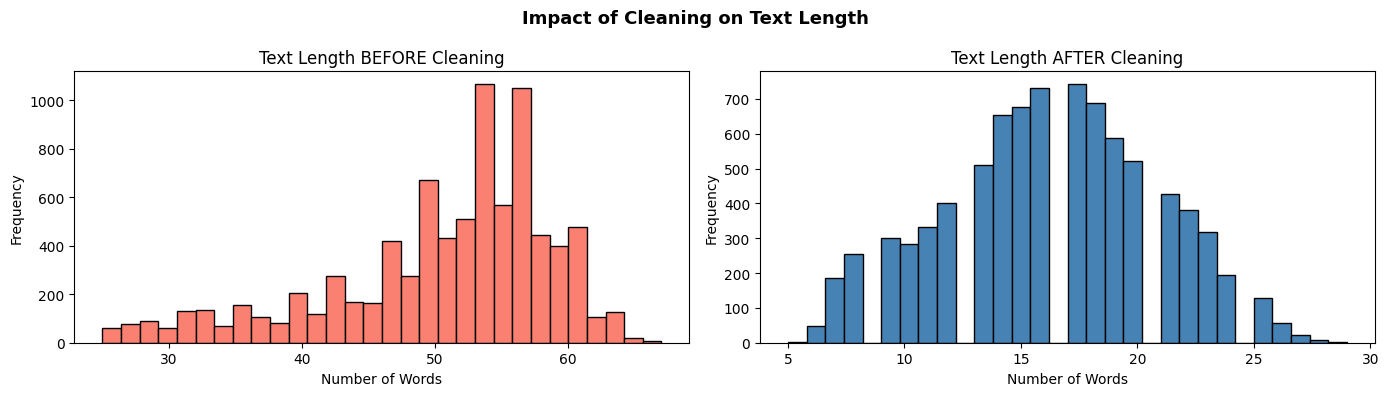


✅ Cleaning rules saved → data/processed/cleaning_rules.json
✅ Cleaned data saved  → data/processed/preprocessed_tickets.csv


In [8]:

# RULE 1 — HANDLE CONTRACTIONS FIRST

CONTRACTIONS = {
    r"i'm\b":       "i am",
    r"i've\b":      "i have",
    r"i'll\b":      "i will",
    r"i'd\b":       "i would",
    r"don't\b":     "do not",
    r"doesn't\b":   "does not",
    r"didn't\b":    "did not",
    r"can't\b":     "cannot",
    r"couldn't\b":  "could not",
    r"won't\b":     "will not",
    r"wouldn't\b":  "would not",
    r"isn't\b":     "is not",
    r"aren't\b":    "are not",
    r"wasn't\b":    "was not",
    r"weren't\b":   "were not",
    r"hasn't\b":    "has not",
    r"haven't\b":   "have not",
    r"hadn't\b":    "had not",
    r"it's\b":      "it is",
    r"that's\b":    "that is",
    r"there's\b":   "there is",
    r"they're\b":   "they are",
    r"we're\b":     "we are",
    r"you're\b":    "you are",
    r"should've\b": "should have",
    r"would've\b":  "would have",
    r"could've\b":  "could have",
}

# RULE 2 — TEMPLATE SENTENCES

TEMPLATE_SENTENCES = [
    r"i purchased .{0,50} on \w+ \d+\w*",
    r"my order number is\s+[a-z0-9\-]+",
    r"my name is\s+[a-z\s]+",
    r"my email is\s+\S+@\S+",
    r"please (help|assist|resolve|fix)\s*(me|this|the issue)?",
    r"i am (writing|contacting|reaching out) (to|because|regarding)",
    r"thank you (for|in advance)\s*[\w\s]*",
    r"i hope (this|you)\s*[\w\s]*",
    r"i look forward to\s*[\w\s]*",
    r"best regards\s*[\w\s]*",
    r"kind regards\s*[\w\s]*",
    r"dear (customer service|support|team|sir|madam)\s*",
    r"to whom it may concern\s*",
    r"i am a (customer|user|subscriber)\s*",
    r"i have been a (customer|user|subscriber)\s*[\w\s]*",
    r"(sincerely|regards|yours truly)\s*[\w\s]*",
    r"ticket (number|id|#)\s*[a-z0-9\-]+",
    r"reference (number|id|#)\s*[a-z0-9\-]+",
    r"case (number|id|#)\s*[a-z0-9\-]+",
    r"account (number|id|#)\s*[a-z0-9\-]+",
    r"i (hope|trust) this (email|message)\s*[\w\s]*",
    r"as per (our|your|the)\s*[\w\s]*",
    r"i am (writing|emailing) (to|regarding|about)\s*",
]

# RULE 3 — PLACEHOLDERS

PLACEHOLDER_PATTERNS = [
    r"\{product_purchased\}",        # specific placeholder found in data
    r"\{[^}]*\}",                    # any {placeholder}
    r"\[[^\]]*\]",                   # any [placeholder]
    r"<[^>]*>",                      # any <placeholder>
    r"\bXXX+\b",
    r"\bN/A\b",
    r"\bTBD\b",
    r"\bTBC\b",
    r"\bnull\b",
    r"\bnone\b",
    r"\bnan\b",
    r"\bna\b",
    r"\b(insert|enter|add)\s+(your|name|date|here)\b",
    r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}",
    r"\d{4}[/-]\d{2}[/-]\d{2}",
    r"\b[A-Z]{2,3}-\d{4,}\b",
    r"\b\d{5,}\b",
    r"\S+@\S+\.\S+",
    r"\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b",
]

# RULE4 — ABBREVIATIONS

ABBREVIATIONS = {
    r"\bapp\b":      "application",
    r"\bapps\b":     "applications",
    r"\bauth\b":     "authentication",
    r"\bconfig\b":   "configuration",
    r"\bdb\b":       "database",
    r"\bdoc\b":      "document",
    r"\bdocs\b":     "documents",
    r"\berr\b":      "error",
    r"\binfo\b":     "information",
    r"\bpw\b":       "password",
    r"\bpwd\b":      "password",
    r"\bpass\b":     "password",
    r"\btech\b":     "technical",
    r"\bui\b":       "user interface",
    r"\burl\b":      "link",
    r"\busr\b":      "user",
    r"\bvpn\b":      "virtual private network",
    r"\bacct\b":     "account",
    r"\baddr\b":     "address",
    r"\bamt\b":      "amount",
    r"\bcust\b":     "customer",
    r"\bdept\b":     "department",
    r"\binv\b":      "invoice",
    r"\bmgr\b":      "manager",
    r"\bmsg\b":      "message",
    r"\bnotif\b":    "notification",
    r"\bord\b":      "order",
    r"\bpmt\b":      "payment",
    r"\bprod\b":     "product",
    r"\bpurch\b":    "purchase",
    r"\bqty\b":      "quantity",
    r"\bref\b":      "reference",
    r"\breq\b":      "request",
    r"\bsubscr\b":   "subscription",
    r"\btrans\b":    "transaction",
    r"\bupd\b":      "update",
    r"\basap\b":     "as soon as possible",
    r"\bpls\b":      "please",
    r"\bplz\b":      "please",
    r"\bthx\b":      "thanks",
    r"\bthnx\b":     "thanks",
    r"\bw/\b":       "with",
    r"\bw/o\b":      "without",
}

# RULE 5 — CUSTOM STOPWORDS

CUSTOM_STOPWORDS = {
    "customer", "support", "service", "team", "issue",
    "problem", "help", "contact", "ticket", "case",
    "request", "response", "reply", "follow", "update",
    "would", "could", "please", "kindly", "need",
    "want", "like", "make", "take", "give", "get",
    "let", "know", "think", "feel", "seems", "appears",
    "today", "yesterday", "ago", "recently", "currently",
    "already", "still", "yet", "since", "always", "never",
    "sometimes", "often", "usually", "immediately",
    "many", "much", "several", "few", "lot", "number",
    "times", "time", "day", "days", "week", "weeks",
    "month", "months", "year", "years", "hour", "hours",
    "really", "very", "quite", "just", "also", "even",
    "well", "way", "thing", "things", "something",
    "anything", "everything", "nothing", "someone",
    "anyone", "everyone", "somehow", "anyway",
    "the", "to", "my", "with", "it", "an", "and",
    "is", "in", "of", "for", "on", "at", "by",
    "be", "as", "or", "but", "not", "are", "was",
    "were", "been", "have", "has", "had", "do",
    "does", "did", "will", "shall", "may", "might",
    "this", "that", "these", "those", "there", "their",
    "they", "them", "we", "our", "you", "your",
    "he", "she", "his", "her", "its", "who", "what",
    "which", "when", "where", "how", "why", "all",
    "each", "both", "from", "about", "into", "through",
    "during", "before", "after", "above", "below",
    "than", "so", "if", "then", "because", "while",
    "although", "however", "therefore", "thus",
    "having", "assist", "im", "ive",
    "product", "purchased", "using",
    "able", "back", "look", "going",
    "come", "try", "find", "use",
    "work", "works", "working",
    "new", "old", "good", "bad",
    "hi", "hello", "hey", "dear",
    "sir", "madam", "mr", "mrs", "ms","can", "any", "other",
    "steps", "noticed", "persists",
}

# ============================================================
# INTEGRATED CLEANING FUNCTION
# ============================================================
def preprocess_text(text):
    # Convert to string safely
    text = str(text).lower()

    # --- RULE 0: Expand contractions FIRST ---
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(contraction, expansion, text)

    # --- RULE 1: Remove template sentences ---
    for pattern in TEMPLATE_SENTENCES:
        text = re.sub(pattern, " ", text)

    # --- RULE 2: Remove placeholders ---
    for pattern in PLACEHOLDER_PATTERNS:
        text = re.sub(pattern, " ", text)

    # --- RULE 3: Standardize abbreviations ---
    for abbr, full in ABBREVIATIONS.items():
        text = re.sub(abbr, full, text)

    # --- RULE 4: Remove punctuation BEFORE stopwords ---
    text = re.sub(r'[^\w\s]', ' ', text)

    # --- RULE 5: Remove custom stopwords ---
    words = text.split()
    words = [w for w in words if w not in CUSTOM_STOPWORDS]
    text = " ".join(words)

    # --- RULE 6: Original cleaning ---
    text = re.sub(r'\d+', '', text)         # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)     # Remove remaining punctuation
    text = re.sub(r'\s+', ' ', text)        # Remove extra spaces
    text = text.strip()

    # --- RULE 7: Remove very short words ---
    words = text.split()
    words = [w for w in words if len(w) > 2]   # Changed from >1 to >2
    text = " ".join(words)

    return text

# ============================================================
# COMBINE TEXT COLUMNS
# ============================================================
def combine_text(row):
    subject     = str(row.get("Ticket Subject", ""))
    description = str(row.get("Ticket Description", ""))
    ticket_type = str(row.get("Ticket Type", ""))
    return subject + " " + description + " " + ticket_type

# ============================================================
# APPLY TO DATAFRAME
# ============================================================
df["combined_text"] = df.apply(combine_text, axis=1)
df["clean_text"]    = df["combined_text"].apply(preprocess_text)

# Drop empty rows
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

# Drop texts too short after cleaning
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))
df = df[df["text_length"] >= 5].reset_index(drop=True)
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

# ============================================================
# PRINT STATS
# ============================================================
print("Average text length:", df["text_length"].mean())
print("Max text length:",     df["text_length"].max())
print("Min text length:",     df["text_length"].min())
print("Total documents:",     len(df))

# ============================================================
# BEFORE vs AFTER COMPARISON
# ============================================================
print("\n" + "=" * 70)
print("BEFORE vs AFTER CLEANING COMPARISON")
print("=" * 70)
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"BEFORE: {df['combined_text'].iloc[i][:200]}")
    print(f"AFTER:  {df['clean_text'].iloc[i][:200]}")

# ============================================================
# TEXT LENGTH PLOTS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

before_lengths = df["combined_text"].apply(lambda x: len(x.split()))
axes[0].hist(before_lengths, bins=30, color="salmon", edgecolor="black")
axes[0].set_title("Text Length BEFORE Cleaning")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["text_length"], bins=30, color="steelblue", edgecolor="black")
axes[1].set_title("Text Length AFTER Cleaning")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Frequency")

plt.suptitle("Impact of Cleaning on Text Length", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# SAVE CLEANING RULES + PROCESSED DATA
# ============================================================
os.makedirs("../../data/processed", exist_ok=True)

cleaning_rules = {
    "contractions":         {k: v for k, v in CONTRACTIONS.items()},
    "template_sentences":   TEMPLATE_SENTENCES,
    "placeholder_patterns": PLACEHOLDER_PATTERNS,
    "abbreviations":        {k: v for k, v in ABBREVIATIONS.items()},
    "custom_stopwords":     list(CUSTOM_STOPWORDS)
}
with open("../../data/processed/cleaning_rules.json", "w") as f:
    json.dump(cleaning_rules, f, indent=2)

df[["clean_text", "Ticket Type", "Ticket Subject", "Ticket Priority", "combined_text",
    "text_length"]].to_csv(
    "../../data/processed/preprocessed_tickets.csv",
    index=False
)

print("\n✅ Cleaning rules saved → data/processed/cleaning_rules.json")
print("✅ Cleaned data saved  → data/processed/preprocessed_tickets.csv")

In [9]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)       # Use unigrams and bigrams
)

X_tfidf = vectorizer.fit_transform(df["clean_text"])
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (8465, 5000)


In [10]:
# Generate sentence embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(
    df["clean_text"].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print("Embeddings Shape:", embeddings.shape)

# Normalize embeddings
embeddings_normalized = normalize(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

Embeddings Shape: (8465, 384)


In [11]:
# Reduce dimensions using UMAP
reducer = umap.UMAP(
    n_components=50,       # Reduce to 50 dimensions for clustering
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
reduced_embeddings = reducer.fit_transform(embeddings_normalized)
print("Reduced Embeddings Shape:", reduced_embeddings.shape)

# Also reduce to 2D for visualization
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
embeddings_2d = reducer_2d.fit_transform(embeddings_normalized)

Reduced Embeddings Shape: (8465, 50)


Best k (TF-IDF): 10
Best k (Embeddings): 8


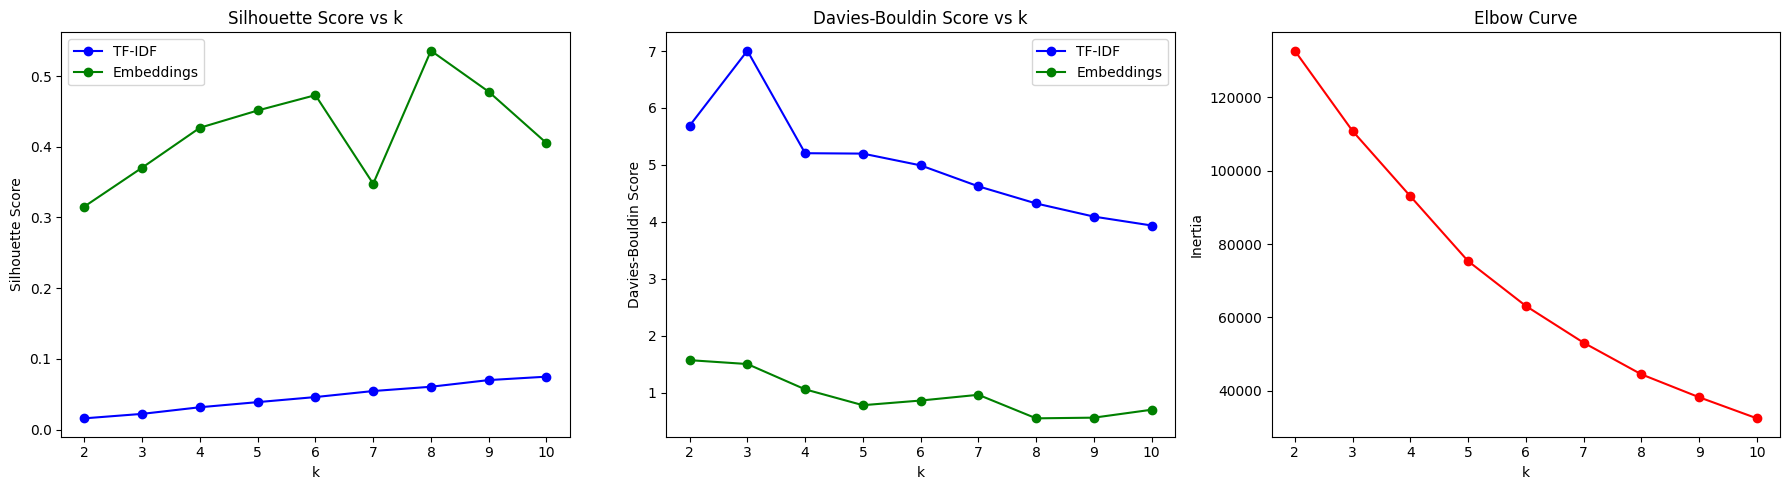

In [12]:
# Evaluate different values of k
silhouette_scores_tfidf = []
silhouette_scores_emb = []
db_scores_tfidf = []
db_scores_emb = []
inertia_scores = []

k_values = range(2, 11)

for k in k_values:
    # TF-IDF clustering
    km_tfidf = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tfidf = km_tfidf.fit_predict(X_tfidf)
    silhouette_scores_tfidf.append(silhouette_score(X_tfidf, labels_tfidf))
    db_scores_tfidf.append(davies_bouldin_score(X_tfidf.toarray(), labels_tfidf))

    # Embeddings clustering
    km_emb = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_emb = km_emb.fit_predict(reduced_embeddings)
    silhouette_scores_emb.append(silhouette_score(reduced_embeddings, labels_emb))
    db_scores_emb.append(davies_bouldin_score(reduced_embeddings, labels_emb))
    inertia_scores.append(km_emb.inertia_)

# Find best k
best_k_tfidf = list(k_values)[silhouette_scores_tfidf.index(max(silhouette_scores_tfidf))]
best_k_emb = list(k_values)[silhouette_scores_emb.index(max(silhouette_scores_emb))]
print(f"Best k (TF-IDF): {best_k_tfidf}")
print(f"Best k (Embeddings): {best_k_emb}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score
axes[0].plot(k_values, silhouette_scores_tfidf, marker="o", label="TF-IDF", color="blue")
axes[0].plot(k_values, silhouette_scores_emb, marker="o", label="Embeddings", color="green")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs k")
axes[0].legend()

# Davies-Bouldin Score
axes[1].plot(k_values, db_scores_tfidf, marker="o", label="TF-IDF", color="blue")
axes[1].plot(k_values, db_scores_emb, marker="o", label="Embeddings", color="green")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies-Bouldin Score")
axes[1].set_title("Davies-Bouldin Score vs k")
axes[1].legend()

# Elbow curve
axes[2].plot(k_values, inertia_scores, marker="o", color="red")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Inertia")
axes[2].set_title("Elbow Curve")

plt.tight_layout()
plt.show()

In [13]:
# Use best k for final clustering
best_k = best_k_emb

# K-Means on TF-IDF
kmeans_tfidf = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_tfidf_cluster"] = kmeans_tfidf.fit_predict(X_tfidf)

# K-Means on Embeddings
kmeans_emb = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_emb_cluster"] = kmeans_emb.fit_predict(reduced_embeddings)

print("K-Means TF-IDF Cluster Distribution:")
print(df["kmeans_tfidf_cluster"].value_counts())

print("\nK-Means Embeddings Cluster Distribution:")
print(df["kmeans_emb_cluster"].value_counts())

K-Means TF-IDF Cluster Distribution:
kmeans_tfidf_cluster
0    3146
1    1630
5     885
6     728
7     675
4     498
3     458
2     445
Name: count, dtype: int64

K-Means Embeddings Cluster Distribution:
kmeans_emb_cluster
1    4935
2    1567
0     720
3     543
7     188
6     183
5     171
4     158
Name: count, dtype: int64


In [14]:
# HAC on TF-IDF
hac_tfidf = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df["hac_tfidf_cluster"] = hac_tfidf.fit_predict(X_tfidf.toarray())

# HAC on Embeddings
hac_emb = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df["hac_emb_cluster"] = hac_emb.fit_predict(reduced_embeddings)

print("HAC TF-IDF Cluster Distribution:")
print(df["hac_tfidf_cluster"].value_counts())

print("\nHAC Embeddings Cluster Distribution:")
print(df["hac_emb_cluster"].value_counts())

HAC TF-IDF Cluster Distribution:
hac_tfidf_cluster
0    6129
1     508
6     337
3     328
2     327
4     326
7     321
5     189
Name: count, dtype: int64

HAC Embeddings Cluster Distribution:
hac_emb_cluster
1    4707
0    1006
7     972
3     720
2     543
4     188
6     171
5     158
Name: count, dtype: int64


In [15]:
results = {
    "Method": [
        "K-Means + TF-IDF",
        "K-Means + Embeddings",
        "HAC + TF-IDF",
        "HAC + Embeddings"
    ],
    "Silhouette Score": [
        silhouette_score(X_tfidf, df["kmeans_tfidf_cluster"]),
        silhouette_score(reduced_embeddings, df["kmeans_emb_cluster"]),
        silhouette_score(X_tfidf.toarray(), df["hac_tfidf_cluster"]),
        silhouette_score(reduced_embeddings, df["hac_emb_cluster"])
    ],
    "Davies-Bouldin Score": [
        davies_bouldin_score(X_tfidf.toarray(), df["kmeans_tfidf_cluster"]),
        davies_bouldin_score(reduced_embeddings, df["kmeans_emb_cluster"]),
        davies_bouldin_score(X_tfidf.toarray(), df["hac_tfidf_cluster"]),
        davies_bouldin_score(reduced_embeddings, df["hac_emb_cluster"])
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Method  Silhouette Score  Davies-Bouldin Score
    K-Means + TF-IDF          0.060526              4.321968
K-Means + Embeddings          0.535984              0.548183
        HAC + TF-IDF          0.039708              3.093857
    HAC + Embeddings          0.499803              0.908236


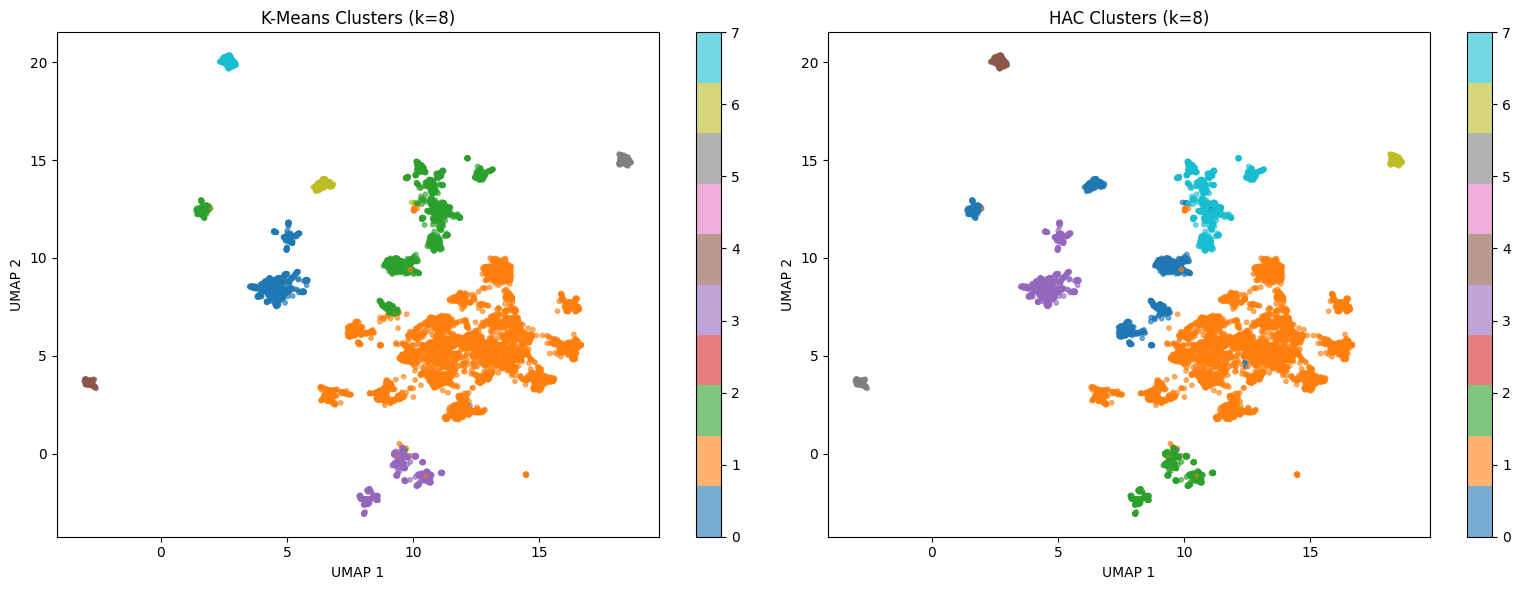

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
scatter1 = axes[0].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["kmeans_emb_cluster"],
    cmap="tab10",
    alpha=0.6,
    s=10
)
axes[0].set_title(f"K-Means Clusters (k={best_k})")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
plt.colorbar(scatter1, ax=axes[0])

# HAC clusters
scatter2 = axes[1].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["hac_emb_cluster"],
    cmap="tab10",
    alpha=0.6,
    s=10
)
axes[1].set_title(f"HAC Clusters (k={best_k})")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

k     Mean Silhouette      Std Dev         Min        Max       
------------------------------------------------------------
2     0.3247               0.0075          0.3155     0.3310    
3     0.3691               0.0080          0.3482     0.3772    
4     0.4188               0.0071          0.4007     0.4270    
5     0.4512               0.0007          0.4490     0.4514    
6     0.4866               0.0047          0.4731     0.4887    
7     0.4419               0.0669          0.3477     0.5162    
8     0.4941               0.0358          0.4497     0.5409    
9     0.4728               0.0685          0.3852     0.5656    
10    0.4469               0.0309          0.4053     0.5050    


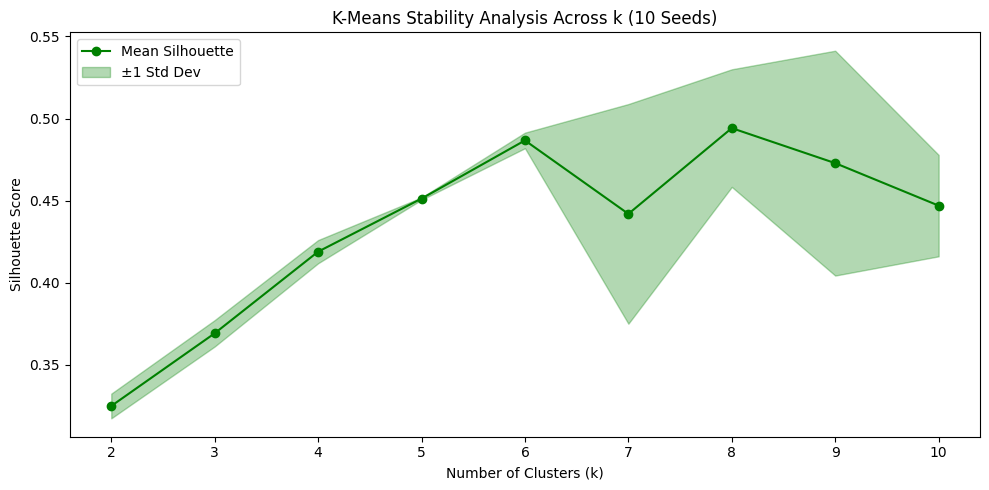

In [17]:
# Run K-Means 10 times with different seeds to check stability
seeds = [0, 7, 21, 42, 99, 123, 256, 512, 777, 999]
stability_results = {}

for k in k_values:
    sil_scores_per_k = []
    for seed in seeds:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(reduced_embeddings)
        sil_scores_per_k.append(silhouette_score(reduced_embeddings, labels))

    stability_results[k] = {
        "mean": np.mean(sil_scores_per_k),
        "std": np.std(sil_scores_per_k),
        "min": np.min(sil_scores_per_k),
        "max": np.max(sil_scores_per_k)
    }

# Print stability table
print(f"{'k':<5} {'Mean Silhouette':<20} {'Std Dev':<15} {'Min':<10} {'Max':<10}")
print("-" * 60)
for k, stats in stability_results.items():
    print(f"{k:<5} {stats['mean']:<20.4f} {stats['std']:<15.4f} {stats['min']:<10.4f} {stats['max']:<10.4f}")

# Plot stability with shaded variance band
means = [stability_results[k]["mean"] for k in k_values]
stds  = [stability_results[k]["std"]  for k in k_values]

plt.figure(figsize=(10, 5))
plt.plot(k_values, means, marker="o", color="green", label="Mean Silhouette")
plt.fill_between(
    k_values,
    [m - s for m, s in zip(means, stds)],
    [m + s for m, s in zip(means, stds)],
    alpha=0.3, color="green", label="±1 Std Dev"
)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Stability Analysis Across k (10 Seeds)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
from kneed import KneeLocator

# Compute inertia for k=2 to 15
k_range = range(2, 16)
inertia_values = []
silhouette_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_embeddings)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(reduced_embeddings, labels))

# Automatically detect elbow point
knee = KneeLocator(
    list(k_range),
    inertia_values,
    curve="convex",
    direction="decreasing"
)
elbow_k = knee.knee
print(f"Automatically detected elbow point: k = {elbow_k}")

Automatically detected elbow point: k = 7


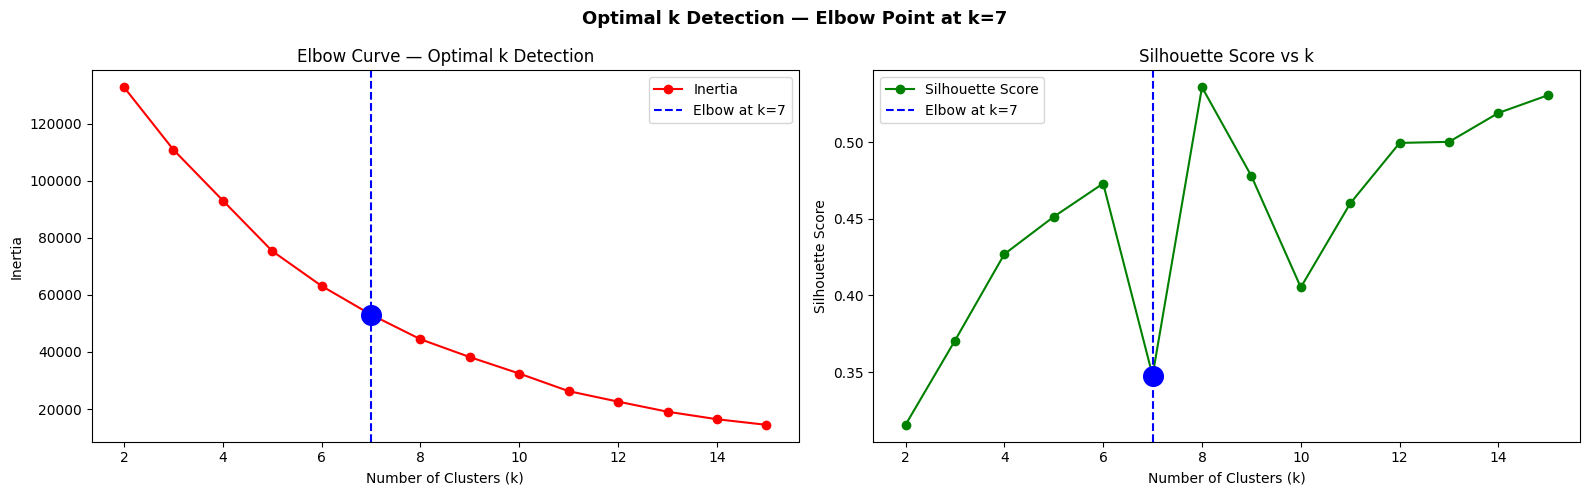


Selected k = 7 based on elbow point
Inertia at k=7:          53079.96
Silhouette Score at k=7: 0.3477


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Elbow Curve ---
axes[0].plot(k_range, inertia_values, marker="o", color="red", label="Inertia")
axes[0].axvline(
    x=elbow_k,
    color="blue",
    linestyle="--",
    label=f"Elbow at k={elbow_k}"
)
axes[0].scatter(
    [elbow_k],
    [inertia_values[elbow_k - 2]],
    color="blue", s=200, zorder=5
)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Curve — Optimal k Detection")
axes[0].legend()

# --- Silhouette Score ---
axes[1].plot(k_range, silhouette_values, marker="o", color="green", label="Silhouette Score")
axes[1].axvline(
    x=elbow_k,
    color="blue",
    linestyle="--",
    label=f"Elbow at k={elbow_k}"
)
axes[1].scatter(
    [elbow_k],
    [silhouette_values[elbow_k - 2]],
    color="blue", s=200, zorder=5
)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
axes[1].legend()

plt.suptitle(
    f"Optimal k Detection — Elbow Point at k={elbow_k}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"\nSelected k = {elbow_k} based on elbow point")
print(f"Inertia at k={elbow_k}:          {inertia_values[elbow_k-2]:.2f}")
print(f"Silhouette Score at k={elbow_k}: {silhouette_values[elbow_k-2]:.4f}")

In [20]:
# Use elbow k 
interpretable_k = elbow_k
print(f"Using k={interpretable_k} from elbow detection")

# Fit K-Means with elbow k
kmeans_interpretable = KMeans(
    n_clusters=interpretable_k,
    random_state=42,
    n_init=10
)
df["interpretable_cluster"] = kmeans_interpretable.fit_predict(reduced_embeddings)

interpretable_sil = silhouette_score(reduced_embeddings, df["interpretable_cluster"])
interpretable_db  = davies_bouldin_score(reduced_embeddings, df["interpretable_cluster"])

print(f"\nInterpretable k={interpretable_k} Results:")
print(f"Silhouette Score:     {interpretable_sil:.4f}")
print(f"Davies-Bouldin Score: {interpretable_db:.4f}")
print(f"\nCluster Distribution:")
print(df["interpretable_cluster"].value_counts().sort_index())

# Show 3 representative tickets per cluster
print("\n--- Representative Tickets Per Cluster ---\n")
for cluster_id in range(interpretable_k):
    cluster_docs = df[df["interpretable_cluster"] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_docs)} tickets):")
    print("-" * 60)
    for i, (_, row) in enumerate(cluster_docs.head(3).iterrows()):
        print(f"  T{i+1}: {row.get('Ticket Subject', row['clean_text'][:80])}")
    print(f"  Ticket Type distribution: {cluster_docs['Ticket Type'].value_counts().to_dict()}")
    print()

Using k=7 from elbow detection

Interpretable k=7 Results:
Silhouette Score:     0.3477
Davies-Bouldin Score: 0.9618

Cluster Distribution:
interpretable_cluster
0     188
1    1766
2    2584
3     720
4     543
5     158
6    2506
Name: count, dtype: int64

--- Representative Tickets Per Cluster ---

Cluster 0 (188 tickets):
------------------------------------------------------------
  T1: Product compatibility
  T2: Product recommendation
  T3: Peripheral compatibility
  Ticket Type distribution: {'Billing inquiry': 42, 'Technical issue': 41, 'Refund request': 39, 'Cancellation request': 36, 'Product inquiry': 30}

Cluster 1 (1766 tickets):
------------------------------------------------------------
  T1: Network problem
  T2: Data loss
  T3: Data loss
  Ticket Type distribution: {'Product inquiry': 380, 'Refund request': 355, 'Cancellation request': 353, 'Billing inquiry': 345, 'Technical issue': 333}

Cluster 2 (2584 tickets):
-----------------------------------------------------

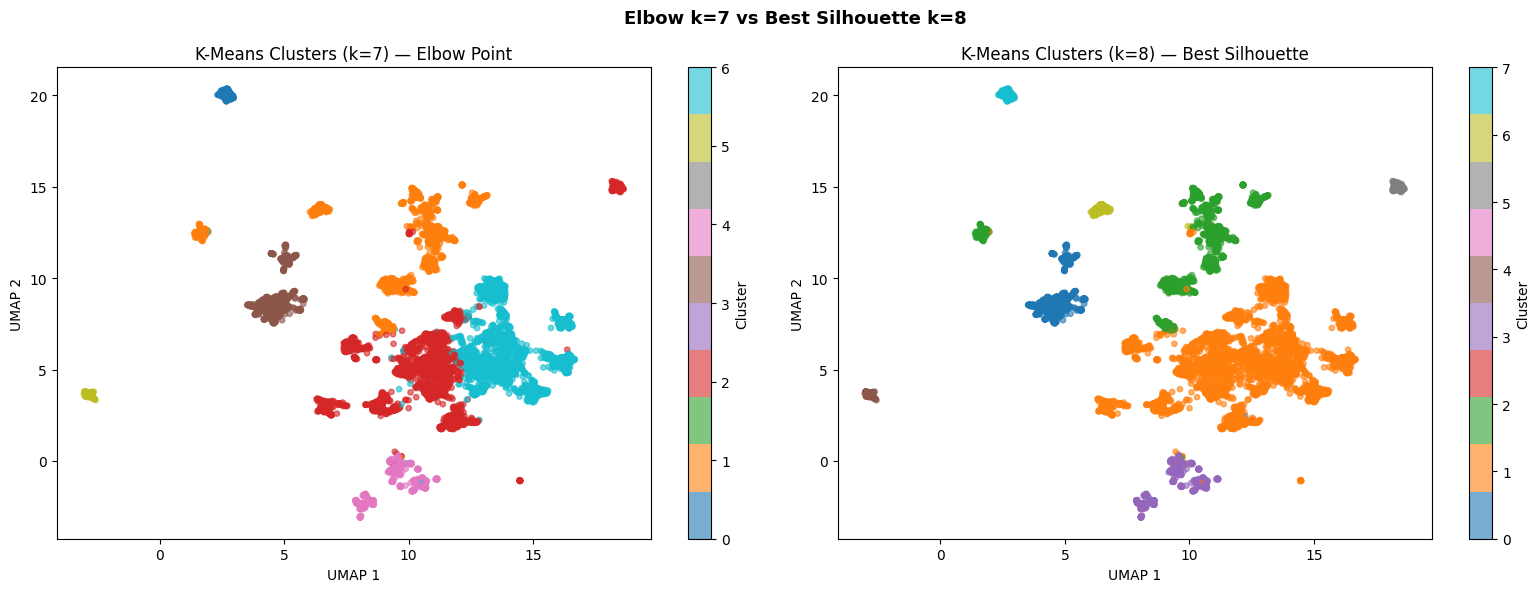

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- K-Means with elbow k ---
scatter1 = axes[0].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["interpretable_cluster"],
    cmap="tab10", alpha=0.6, s=15
)
axes[0].set_title(f"K-Means Clusters (k={interpretable_k}) — Elbow Point")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# --- Elbow curve inset for reference ---
scatter2 = axes[1].scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=df["kmeans_emb_cluster"],
    cmap="tab10", alpha=0.6, s=15
)
axes[1].set_title(f"K-Means Clusters (k={best_k}) — Best Silhouette")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(scatter2, ax=axes[1], label="Cluster")

plt.suptitle(
    f"Elbow k={interpretable_k} vs Best Silhouette k={best_k}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [22]:
baseline_summary = {
    "method": "K-Means + Sentence Embeddings + UMAP",
    "k_selection_method": "Elbow point detection using KneeLocator",
    "k": int(interpretable_k),                        # ← add int()
    "silhouette_score": round(float(interpretable_sil), 4),   # ← add float()
    "davies_bouldin_score": round(float(interpretable_db), 4), # ← add float()
    "interpretation": f"{int(interpretable_k)} ticket categories identified via elbow method",
    "representative_clusters": {}
}

for cluster_id in range(interpretable_k):
    cluster_docs = df[df["interpretable_cluster"] == cluster_id]
    baseline_summary["representative_clusters"][f"cluster_{cluster_id}"] = {
        "size": int(len(cluster_docs)),               # ← add int()
        "ticket_type_distribution": {
            k: int(v) for k, v in                    # ← convert values to int
            cluster_docs["Ticket Type"].value_counts().to_dict().items()
        },
        "sample_subjects": cluster_docs.get(
            "Ticket Subject",
            cluster_docs["clean_text"]
        ).head(3).tolist()
    }

print(json.dumps(baseline_summary, indent=2))

{
  "method": "K-Means + Sentence Embeddings + UMAP",
  "k_selection_method": "Elbow point detection using KneeLocator",
  "k": 7,
  "silhouette_score": 0.3477,
  "davies_bouldin_score": 0.9618,
  "interpretation": "7 ticket categories identified via elbow method",
  "representative_clusters": {
    "cluster_0": {
      "size": 188,
      "ticket_type_distribution": {
        "Billing inquiry": 42,
        "Technical issue": 41,
        "Refund request": 39,
        "Cancellation request": 36,
        "Product inquiry": 30
      },
      "sample_subjects": [
        "Product compatibility",
        "Product recommendation",
        "Peripheral compatibility"
      ]
    },
    "cluster_1": {
      "size": 1766,
      "ticket_type_distribution": {
        "Product inquiry": 380,
        "Refund request": 355,
        "Cancellation request": 353,
        "Billing inquiry": 345,
        "Technical issue": 333
      },
      "sample_subjects": [
        "Network problem",
        "Data los